# Explore anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
mse_cols = ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
mse_rel_cols = ['mse_rel', 'mse_filter_250_rel', 'mse_97_rel', 'mse_filter_250_97_rel']

In [4]:
mse_family = ['mse', 'mse_97', 'mse_filter_250', 'mse_filter_250_97']
chi_sq_family = ['mse_rel', 'mse_97_rel', 'mse_filter_250_rel', 'mse_filter_250_97_rel']

# Custom functions

## Scores arr to df

In [5]:
def scores_arr_to_df(score_paths, bin_idx_to_specobjid):

    score_names = [score.split("/")[-1][:-4] for score in score_paths]
    objids_bin = bin_idx_to_specobjid[:, 1]

    scores_dict = {}

    for score_name, score_path in zip(score_names, score_paths):

        scores_dict[score_name] = np.load(score_path)[:, 0]

    scores_df = pd.DataFrame(data=scores_dict, index=objids_bin)
    scores_df.index.name = 'specobjid'
    scores_df.sort_values(by='mse', ascending=False, inplace=True)

    return scores_df[mse_cols + mse_rel_cols]


## Residuals

In [6]:
def residual_mse(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)
    
    return flux_diff

## Score dist

In [7]:
def plot_hist_scores(
    df,
    score_family,
    x_label,
    bins=100
):
    """
    Generates a 2x2 grid of histograms for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=(20, 9)
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        _ = axs[i].hist(
            df[score], 
            bins=bins,
            color='tab:blue', edgecolor='black',
            linewidth=0.5
        )
        axs[i].set_yscale('log')
        # Formatting
        axs[i].minorticks_on()
        axs[i].text(
            0.95, 0.95,
            score,
            horizontalalignment="right", verticalalignment="center",
            transform=axs[i].transAxes,
            fontsize=12
        )

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)

    return fig, axs

## score Vs z \& S/N

In [8]:
def plot_hist_score_z_snr(
    df,
    score_family,
    x_col, x_label,
    gridsize=100
):
    """
    Generates a 2x2 grid of hexbin plots for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=(20, 9)
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        hb = axs[i].hexbin(
            df[x_col], 
            df[score], 
            gridsize=gridsize, 
            cmap='viridis',
            mincnt=1, 
            bins='log'
        )
        
        # Formatting
        axs[i].minorticks_on()
        axs[i].text(
            0.95, 0.95,
            score,
            horizontalalignment="right", verticalalignment="center",
            transform=axs[i].transAxes,
            fontsize=12
        )

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)
        
        # Add colorbar
        cb = fig.colorbar(hb, ax=axs[i])
        if i == 1 or i == 3:
            cb.set_label('Log10(Count)')

    return fig, axs

# Config

## Directories

In [9]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_ids = [f"bin_{i:02d}" for i in range(4)]
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

## Data

In [10]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)
# idx_id_03 = np.load(
#     f"{spectra_dir}/bin_03/bin_03_index_specobjid.npy"
# )

## Model

In [11]:
ae_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_03/winner",
)

## Build csv with scores for each bin

```python
bin_id = 'bin_03'

score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

bin_idx_to_specobjid = np.load(
    f"{spectra_dir}/"
    f"{bin_id}/{bin_id}_index_specobjid.npy"
)

scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
scores_df.to_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index=True
)
```

```python
for bin_id in bin_ids:

    score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

    bin_idx_to_specobjid = np.load(
        f"{spectra_dir}/"
        f"{bin_id}/{bin_id}_index_specobjid.npy"
    )

    scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
    scores_df.to_csv(
        f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
        index=True
    )
```

# Bind 03 Scores 

In [13]:
bin_id = 'bin_03'
score_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

In [14]:
n_spec = score_03_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]

In [15]:
n_tops, n_tops_perc

([181, 909, 1818, 9092], ['0.10%', '0.50%', '1.00%', '5.00%'])

# Illustration of scores

## Data prep

In [15]:
bad_specobjid = 531492683672217600
idx_bad = specobjid_to_idx(bad_specobjid, idx_id_spec)
spec_bad = spectra[idx_bad]
spec_bad_rec = ae_03.reconstruct(spec_bad).reshape(-1)
residual_bad = residual_mse(spec_bad, spec_bad_rec)
threshold_bad_3 = np.nanpercentile(residual_bad, 97)
print(f"Ignore 3% threshold: {threshold_bad_3}")
# -------------------------------------------------
broad_specobjid = 1924292192684238848
idx_broad = specobjid_to_idx(broad_specobjid, idx_id_spec)
spec_broad = spectra[idx_broad]
spec_broad_rec = ae_03.reconstruct(spec_broad).reshape(-1)
residual_broad = residual_mse(spec_broad, spec_bad_rec)
threshold_broad_3 = np.nanpercentile(residual_broad, 97)
print(f"Ignore 3% threshold: {threshold_broad_3}")
# -------------------------------------------------
score_03_df.loc[[bad_specobjid, broad_specobjid]]

Ignore 3% threshold: 0.32456904888153054
Ignore 3% threshold: 0.9424101758003136


,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
specobjid,,,,,,,,
531492683672217600,9.005151,8.881266,7.313005,7.277526,9.325896,9.277807,7.933616,7.901201
1924292192684238848,11.063046,10.985553,3.475676,3.437868,6.298067,6.281447,3.264227,3.244473


In [16]:
emission_lines = list(GALAXY_LINES.keys())

velocity_fil_fn = VelocityFilter(
    wave=wave, velocity_filter=250,
    lines=emission_lines
)

vel_mask = velocity_fil_fn.get_velocity_filter_mask()

## Figure

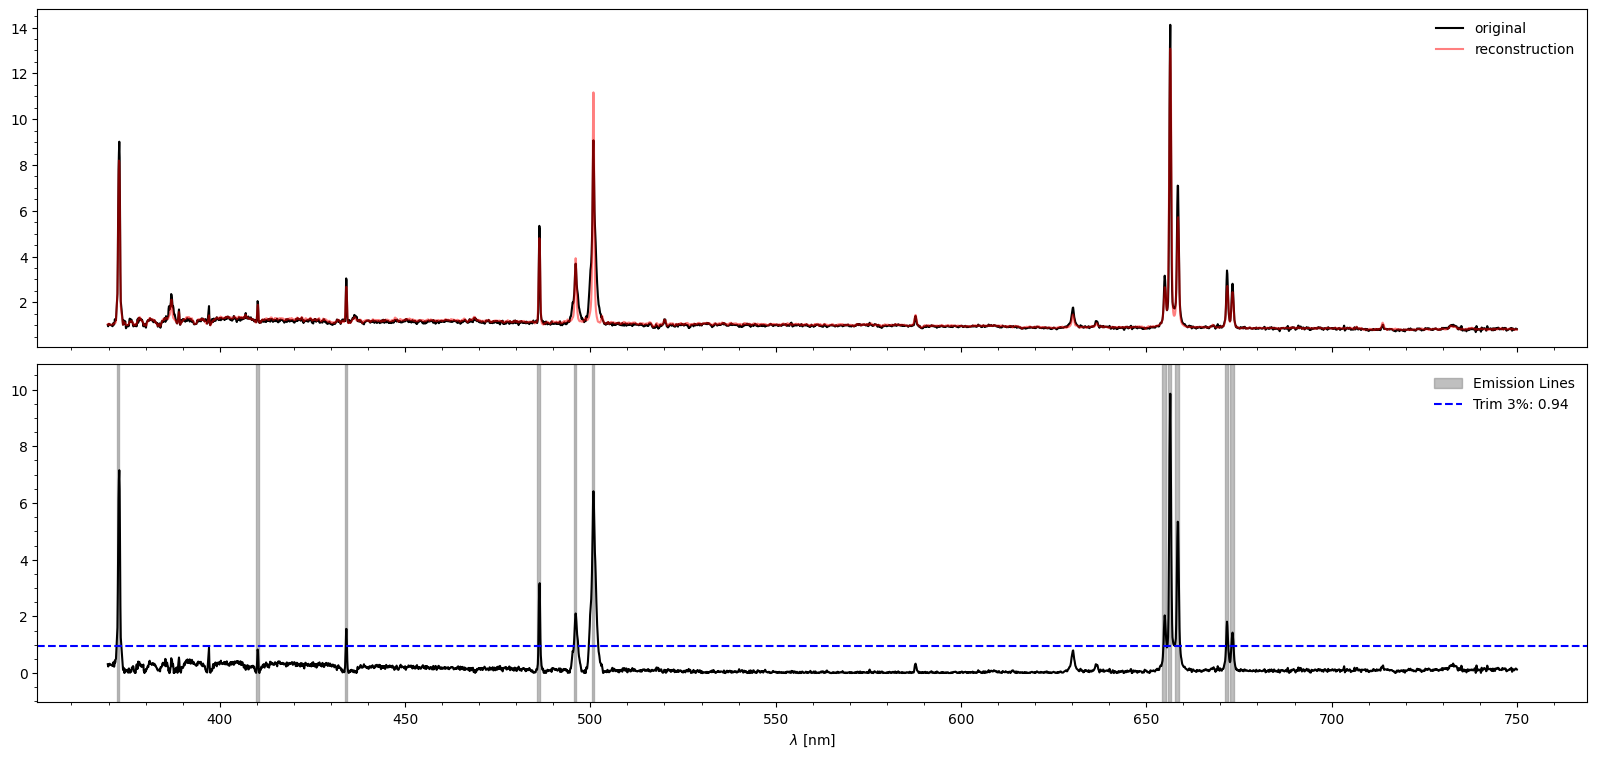

In [17]:
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(20, 9)
)
# ----------------------------------------------------
axs[0].plot(wave_nm, spec_broad, color='black', alpha=1, label='original')
axs[0].plot(wave_nm, spec_broad_rec, color='red', alpha=0.5, label='reconstruction')
# ----------------------------------------------------
axs[1].plot(wave_nm, residual_broad, color='black')
# ----------------------------------------------------
# shaded regions
    
axs[1].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Emission Lines'
)
# ----------------------------------------------------
# Lower Panel Right: Broad Residuals
axs[1].axhline(
    y=threshold_broad_3, 
    color='blue', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Trim 3%: {threshold_broad_3:.2f}'
)

# ----------------------------------------------------
# leggends
axs[0].legend(loc='upper right', frameon=False, fontsize=10)
axs[1].legend(loc='upper right', frameon=False, fontsize=10)
# ---------------------------------------------------- 
for ax in axs.flatten(): ax.minorticks_on()
# ---------------------------------------------------- 

axs[1].set_xlabel(r"$\lambda$ [nm]")
# ---------------------------------------------------- 
plt.subplots_adjust(hspace=0.05, wspace=0.05)
# ---------------------------------------------------- 
fig.savefig(
    f"{ch_4_dir}/score_methodology_example.pdf",
    bbox_inches='tight'
)

# Histograms Scores

## Data prep

In [18]:
merged_df = score_03_df.join(final_meta_df[['z', 'snMedian']], how='inner').copy()
score_cols = mse_cols + mse_rel_cols
merged_df[score_cols] = merged_df[score_cols] / merged_df[score_cols].max()

In [19]:
bad_specobjid = 531492683672217600
broad_specobjid = 1924292192684238848
merged_df.loc[[bad_specobjid, broad_specobjid], score_cols]

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
specobjid,,,,,,,,
531492683672217600,0.175614,0.173200,0.508545,0.507042,0.380195,0.378722,0.514787,0.513339
1924292192684238848,0.215746,0.214237,0.241698,0.239524,0.256757,0.256410,0.211805,0.210793


## Score descriptive stats

In [20]:
merged_df[score_cols].describe(
    percentiles=np.linspace(0.1, 0.9, 9)
)

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
count,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000
mean,0.047143,0.046772,0.134811,0.134593,0.109399,0.108550,0.138365,0.137927
std,0.017707,0.017343,0.032916,0.032825,0.028815,0.028146,0.031275,0.031189
min,0.015033,0.014265,0.039336,0.039193,0.035866,0.035384,0.041414,0.041269
10%,0.030759,0.030540,0.091548,0.091401,0.074758,0.074039,0.096006,0.095666
20%,0.035833,0.035616,0.106595,0.106432,0.086557,0.085872,0.111162,0.110803
30%,0.039734,0.039506,0.118005,0.117846,0.095468,0.094782,0.122594,0.122187
40%,0.043062,0.042821,0.127603,0.127419,0.102955,0.102266,0.132220,0.131814
50%,0.046003,0.045753,0.136118,0.135929,0.109575,0.108873,0.140805,0.140369
60%,0.048766,0.048496,0.143994,0.143809,0.115787,0.115097,0.148553,0.148106


## Top 1% score thresholds

In [21]:
top_1_thresholds = merged_df[score_cols].quantile(0.99)
print("Score thresholds for the Top 1% of anomalies:")
print("-" * 40)
print(top_1_thresholds)

Score thresholds for the Top 1% of anomalies:
----------------------------------------
mse                      0.098397
mse_filter_250           0.095843
mse_97                   0.216048
mse_filter_250_97        0.215365
mse_rel                  0.183983
mse_filter_250_rel       0.180896
mse_97_rel               0.208514
mse_filter_250_97_rel    0.207819
Name: 0.99, dtype: float64


## MSE family dist

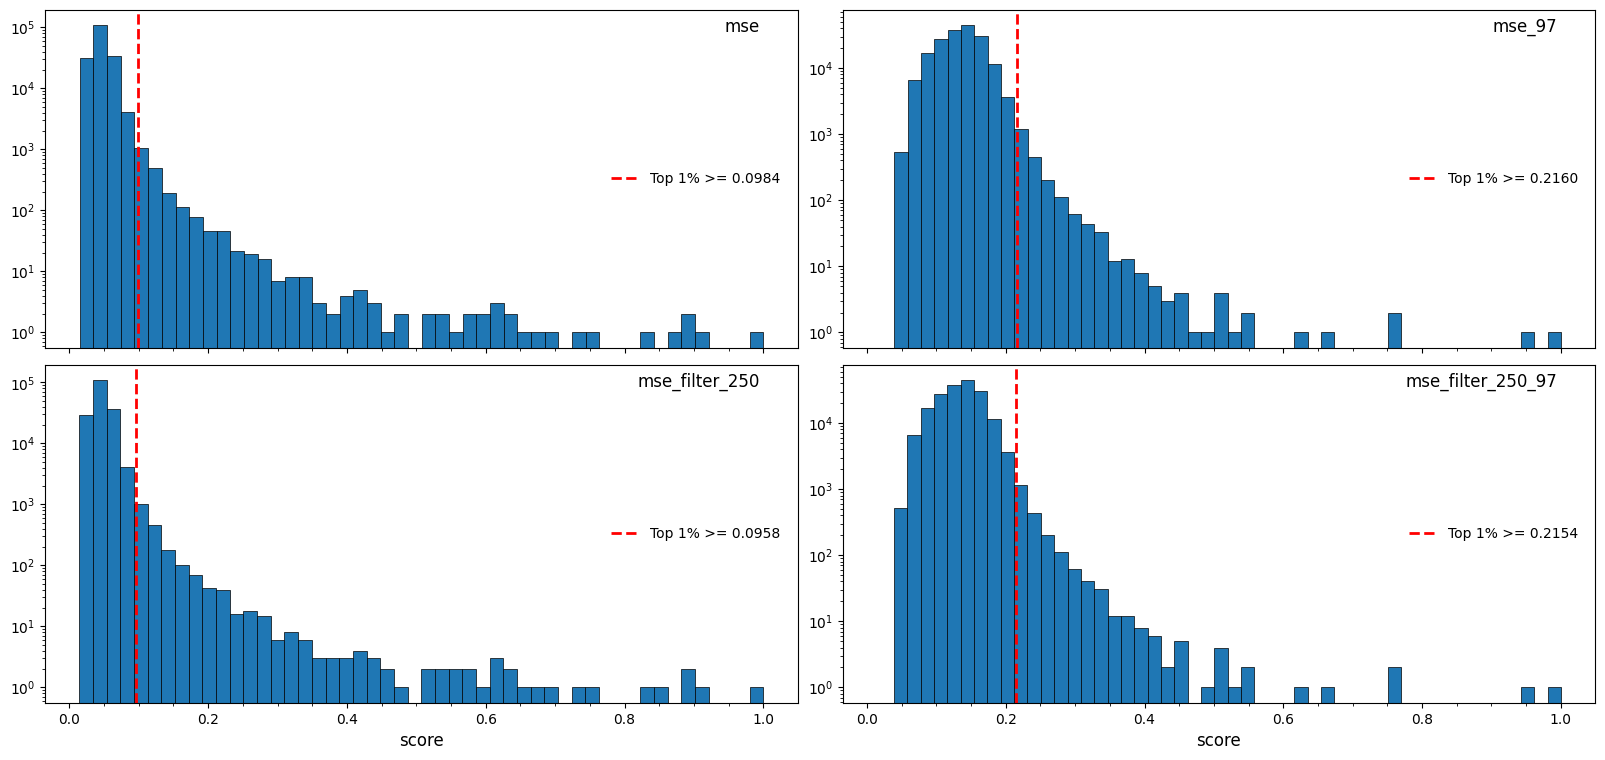

In [22]:
fig, axs = plot_hist_scores(
    merged_df,
    mse_family,
    x_label='score',
    bins=50
)

for i, score in enumerate(mse_family):

    axs[i].axvline(
        x=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    axs[i].legend(frameon=False)

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)

## Chi sq family dist

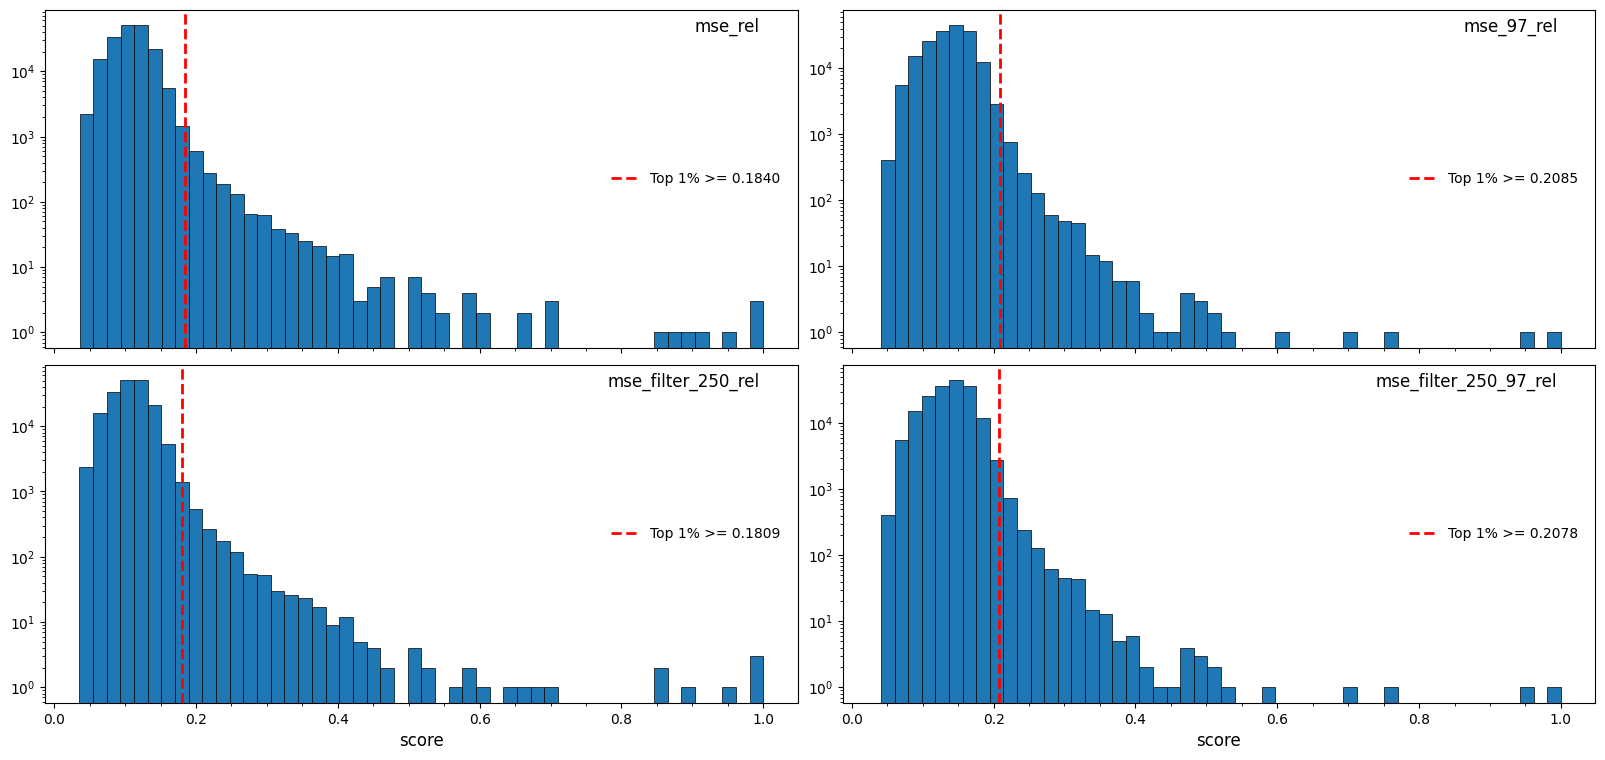

In [23]:
fig, axs = plot_hist_scores(
    merged_df,
    chi_sq_family,
    x_label='score',
    bins=50
)

for i, score in enumerate(chi_sq_family):

    axs[i].axvline(
        x=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    axs[i].legend(frameon=False)

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)

# Scores overlap

In [24]:
(
    ids_a, ids_b,
    common_ids,
    only_in_a, only_in_b
) = AnomalyOverlapAnalyzer.overlap_pair_scores(
    score_a='mse',
    score_b='mse_filter_250',
    df=merged_df.copy(),
    quantile=99
)

overlap_pct = (len(common_ids)/len(ids_a))*100
f"{overlap_pct:.2f}%", len(ids_a), len(common_ids), len(only_in_a), len(only_in_b)

('94.23%', 1819, 1714, 105, 105)

In [25]:
all_scores = mse_cols + mse_rel_cols

overlap_df = pd.DataFrame(
    index=all_scores,
    columns=all_scores,
    dtype=float
)

for score_a in all_scores:

    for score_b in all_scores:

        if score_a == score_b:

            overlap_df.loc[score_a, score_b] = 100.0

        else:
            ids_a, ids_b, common, _, _ = AnomalyOverlapAnalyzer.overlap_pair_scores(
                score_a, score_b, merged_df
            )
            
            pct = (len(common) / len(ids_a)) * 100
            overlap_df.loc[score_a, score_b] = pct

overlap_df.round(2)

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
mse,100.00,94.23,49.15,48.98,64.49,60.64,38.98,38.65
mse_filter_250,94.23,100.00,50.03,49.81,62.95,62.89,40.13,39.75
mse_97,49.15,50.03,100.00,99.07,51.18,53.93,70.70,70.64
mse_filter_250_97,48.98,49.81,99.07,100.00,51.13,53.88,70.75,70.86
mse_rel,64.49,62.95,51.18,51.13,100.00,92.36,51.40,51.13
mse_filter_250_rel,60.64,62.89,53.93,53.88,92.36,100.00,55.47,55.20
mse_97_rel,38.98,40.13,70.70,70.75,51.40,55.47,100.00,98.68
mse_filter_250_97_rel,38.65,39.75,70.64,70.86,51.13,55.20,98.68,100.00


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, 'mse'),
  Text(0, 1.5, 'mse_filter_250'),
  Text(0, 2.5, 'mse_97'),
  Text(0, 3.5, 'mse_filter_250_97'),
  Text(0, 4.5, 'mse_rel'),
  Text(0, 5.5, 'mse_filter_250_rel'),
  Text(0, 6.5, 'mse_97_rel'),
  Text(0, 7.5, 'mse_filter_250_97_rel')])

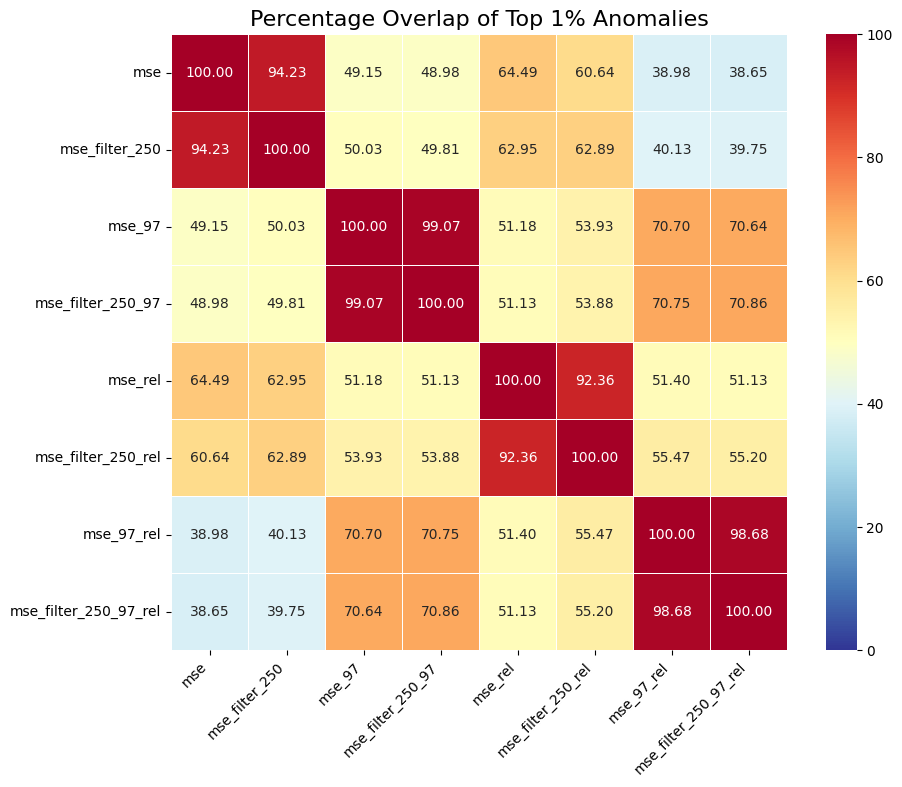

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    overlap_df, 
    annot=True,       # Show the numbers in the squares
    fmt=".2f",        # Format as integers (e.g., "85") or ".1f" for "85.2"
    cmap="RdYlBu_r",  # Red-Yellow-Blue reversed (Red=High Overlap, Blue=Low)
    vmin=0, vmax=100, # Fix scale from 0 to 100%
    linewidths=0.5,   # Grid lines
    square=True       # Force square cells
)
plt.title("Percentage Overlap of Top 1% Anomalies", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Median Specs

In [27]:
n_spec = merged_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]
n_tops, n_tops_perc

([181, 909, 1818, 9092], ['0.10%', '0.50%', '1.00%', '5.00%'])

## MSE family

In [28]:
n_top_1_per_anomalies = int(n_spec*0.01)

specids_mse_top_1_dict = {}

for score in mse_cols:

    specids_top_1 = merged_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_per_anomalies]

    specids_mse_top_1_dict[score] = specids_top_1

In [29]:
spec_idx_mse_top_1_dict = {}

for score in mse_cols:
    
    spec_idx_list = []

    for objid in specids_mse_top_1_dict[score]:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)
    
    spec_idx_mse_top_1_dict[score] = spec_idx_list

### Spec prep

In [30]:
spec_mse = spectra[spec_idx_mse_top_1_dict['mse']]
spec_mse_median = np.nanmedian(spec_mse, axis=0)
spec_mse_mean = np.nanmean(spec_mse, axis=0)
# ------------------------------------------------------
spec_mse_filter = spectra[spec_idx_mse_top_1_dict['mse_filter_250']]
spec_mse_filter_median = np.nanmedian(spec_mse_filter, axis=0)
spec_mse_filter_mean = np.nanmean(spec_mse_filter, axis=0)
# ------------------------------------------------------
spec_trim = spectra[spec_idx_mse_top_1_dict['mse_97']]
spec_trim_median =  np.nanmedian(spec_trim, axis=0)
spec_trim_mean =  np.nanmean(spec_trim, axis=0)
# ------------------------------------------------------
spec_filter_trim = spectra[spec_idx_mse_top_1_dict['mse_filter_250_97']]
spec_filter_trim_median = np.nanmedian(spec_filter_trim, axis=0)
spec_filter_trim_mean = np.nanmean(spec_filter_trim, axis=0)


### Median spec

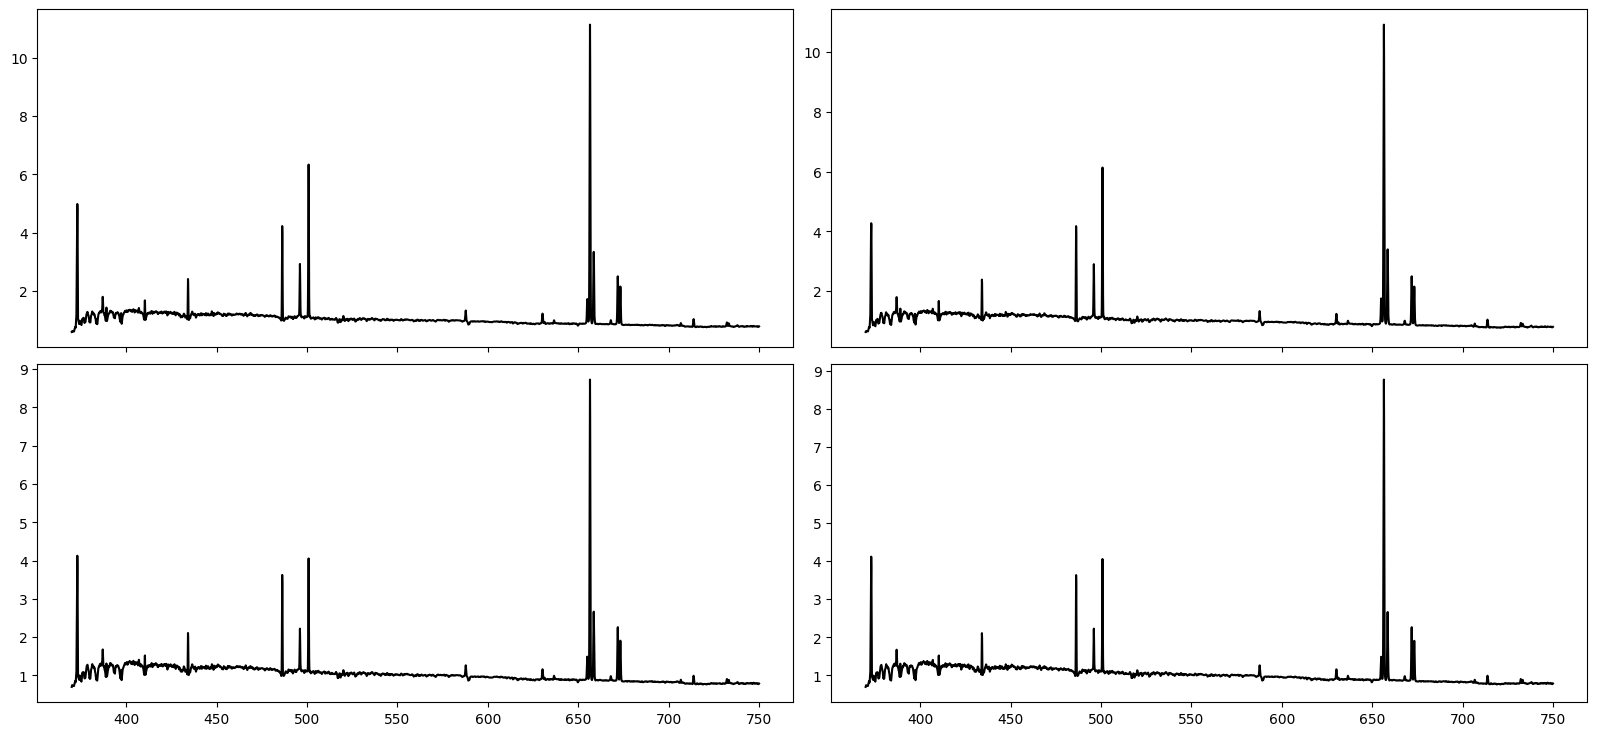

In [31]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_mse_median, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_mse_filter_median, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_trim_median, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_filter_trim_median, color='black')

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

## Mean spec

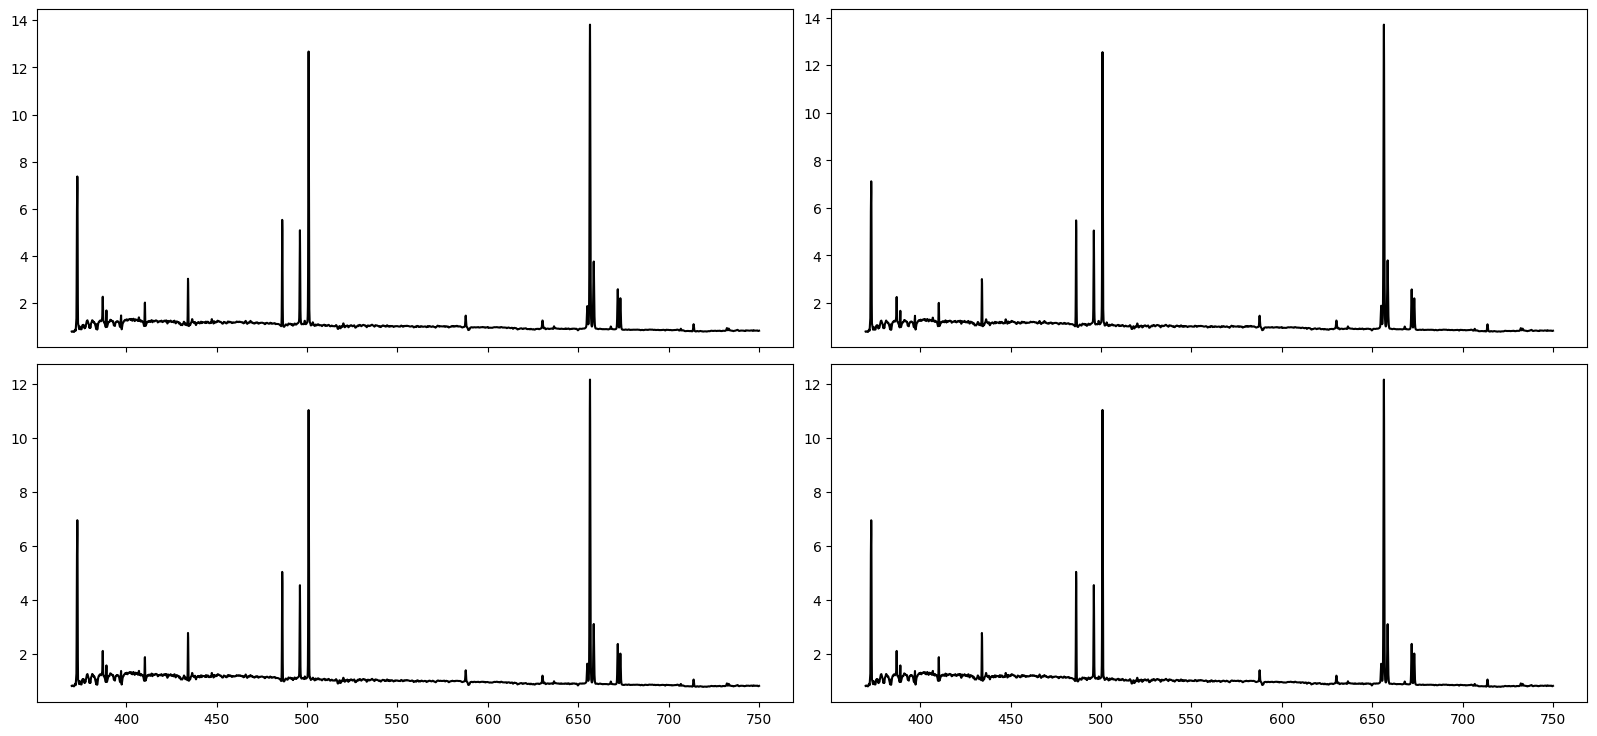

In [32]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_mse_mean, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_mse_filter_mean, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_trim_mean, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_filter_trim_mean, color='black')

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

## Chi sq family

In [33]:
n_top_1_per_anomalies = int(n_spec*0.01)

specids_chi_sq_top_1_dict = {}

for score in mse_rel_cols:

    specids_top_1 = merged_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_per_anomalies]

    specids_chi_sq_top_1_dict[score] = specids_top_1

In [34]:
spec_idx_chi_sq_top_1_dict = {}

for score in mse_rel_cols:
    
    spec_idx_list = []

    for objid in specids_chi_sq_top_1_dict[score]:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)
    
    spec_idx_chi_sq_top_1_dict[score] = spec_idx_list

### Spec prep

In [35]:
spec_chi = spectra[spec_idx_chi_sq_top_1_dict['mse_rel']]
spec_chi_median = np.nanmedian(spec_chi, axis=0)
# ------------------------------------------------------
spec_chi_filter = spectra[spec_idx_chi_sq_top_1_dict['mse_filter_250_rel']]
spec_chi_filter_median = np.nanmedian(spec_chi_filter, axis=0)
# ------------------------------------------------------
spec_chi_trim = spectra[spec_idx_chi_sq_top_1_dict['mse_97_rel']]
spec_chi_trim_median =  np.nanmedian(spec_chi_trim, axis=0)
# ------------------------------------------------------
spec_chi_filter_trim = spectra[spec_idx_chi_sq_top_1_dict['mse_filter_250_97_rel']]
spec_chi_filter_trim_median = np.nanmedian(spec_chi_filter_trim, axis=0)


### Plot median spec

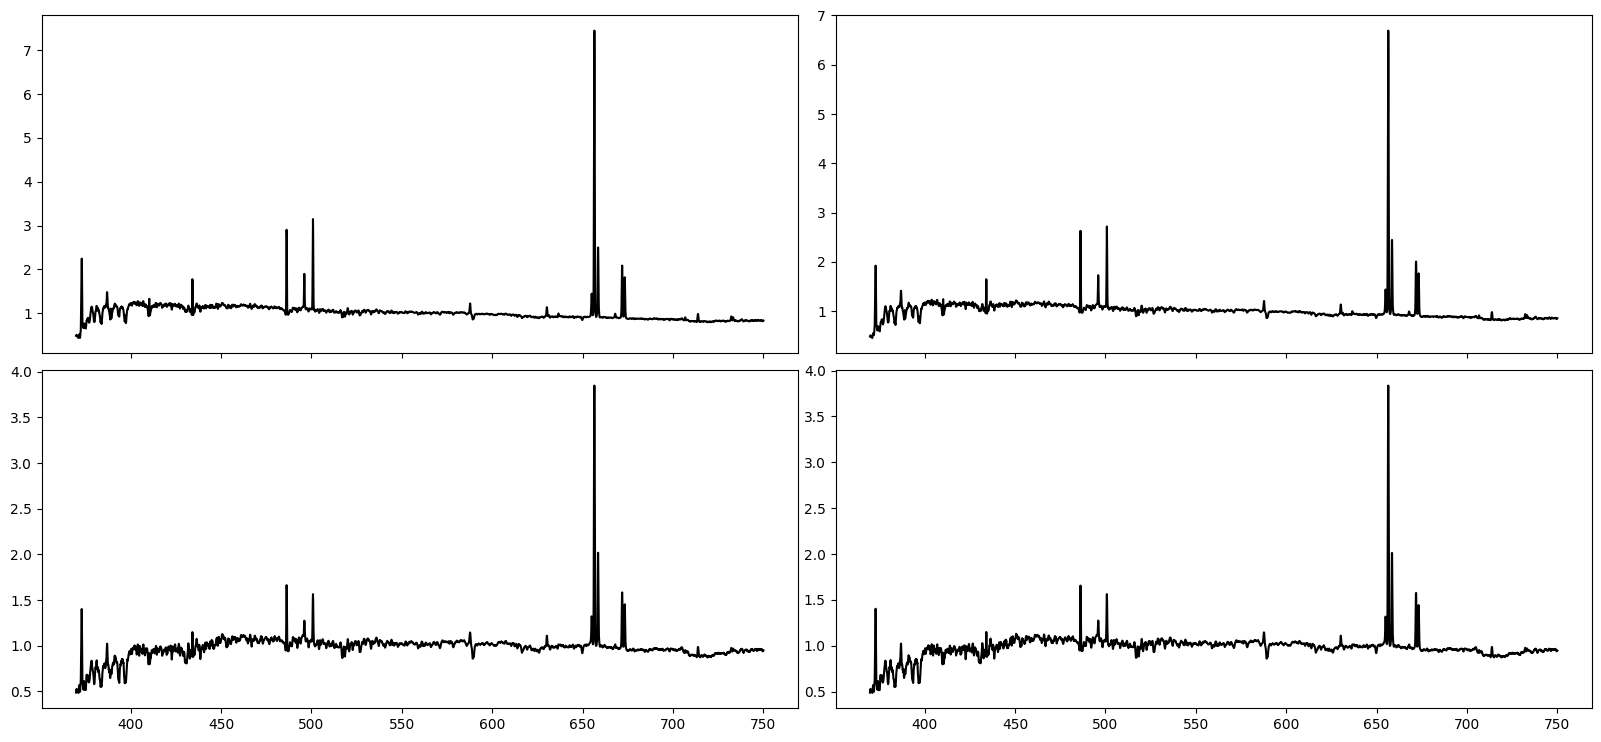

In [36]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_chi_median, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_chi_filter_median, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_chi_trim_median, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_chi_filter_trim_median, color='black')

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

# Metadata histograms

## Redshift

In [37]:
z_quantile = 95
top_z_threshold = merged_df['z'].quantile(z_quantile/100)
print(f"z quantile: {z_quantile}%:")
print("-" * 40)
print(top_z_threshold)

z quantile: 95%:
----------------------------------------
0.1469246399999999


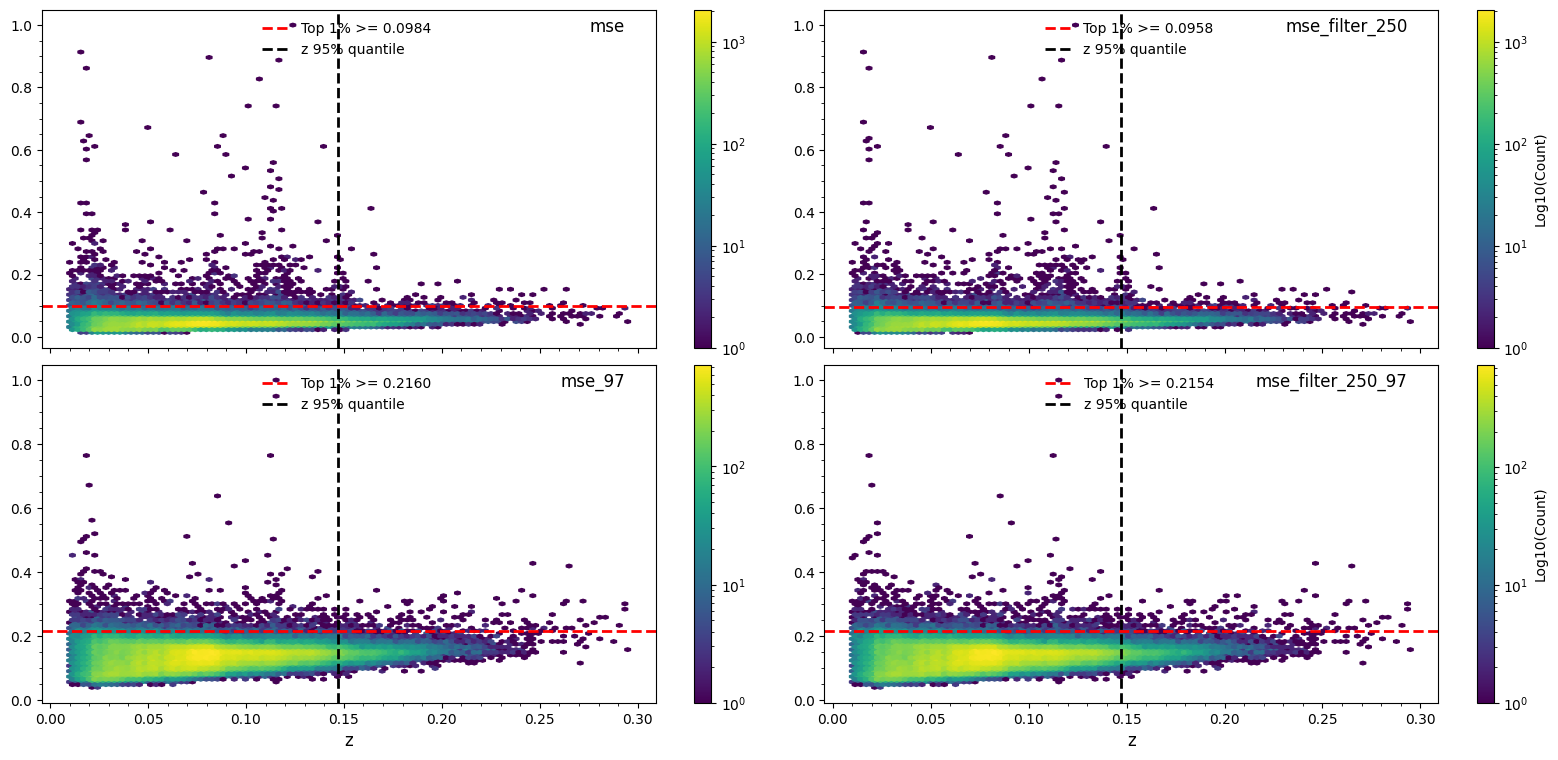

In [38]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_cols, 'z', 'z')

for i, score in enumerate(mse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    axs[i].axvline(
        x=top_z_threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'z {z_quantile}% quantile'
    )

    axs[i].legend(frameon=False, loc='upper center')


plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

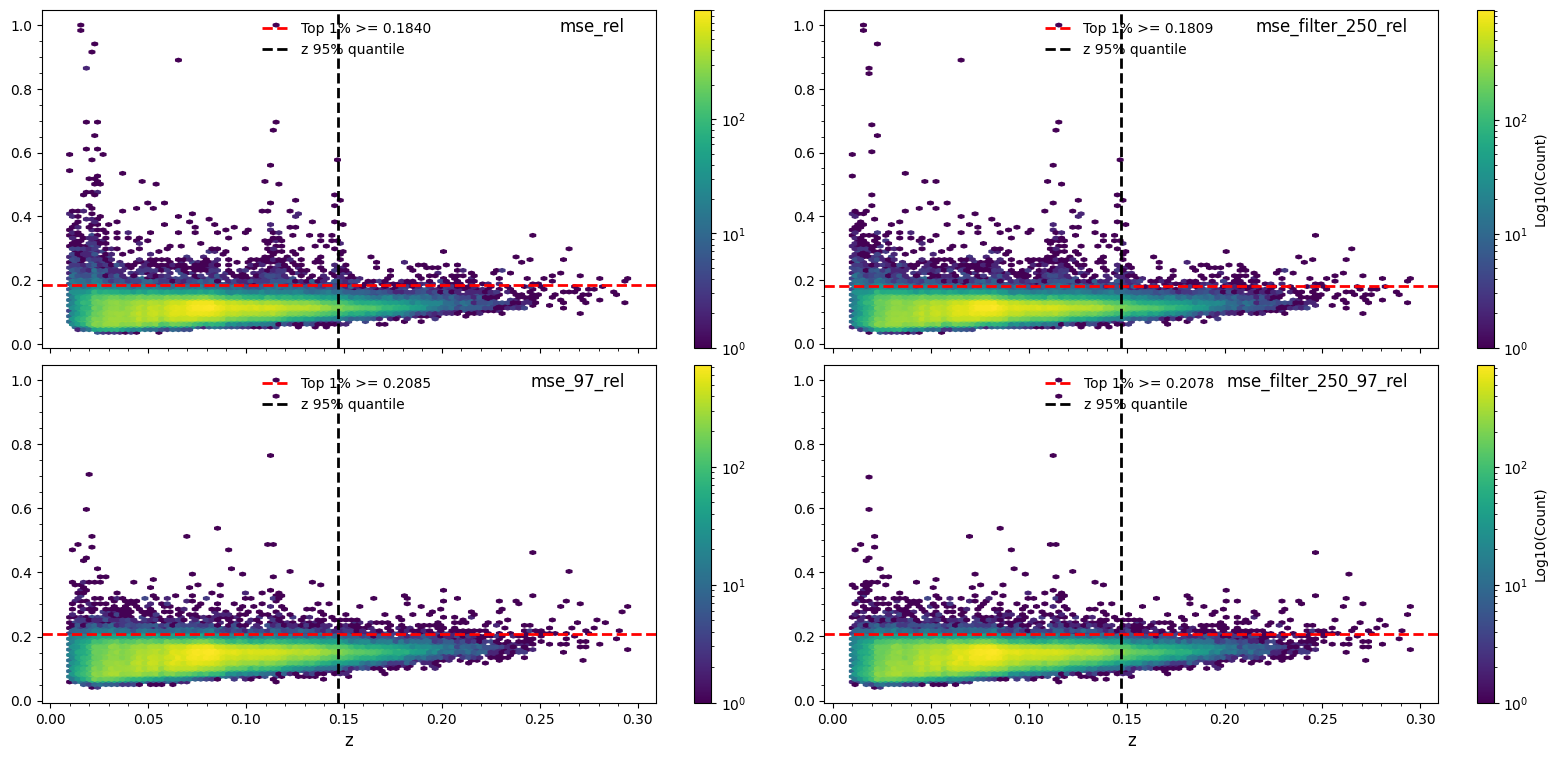

In [39]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_rel_cols, 'z', 'z')

for i, score in enumerate(mse_rel_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    axs[i].axvline(
        x=top_z_threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'z {z_quantile}% quantile'
    )

    axs[i].legend(frameon=False, loc='upper center')

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

## S/N

In [40]:
snr_quantile = 95
top_snr_threshold = merged_df['snMedian'].quantile(snr_quantile/100)
print(f"z quantile: {snr_quantile}%:")
print("-" * 40)
print(top_snr_threshold)

z quantile: 95%:
----------------------------------------
37.952049499999994


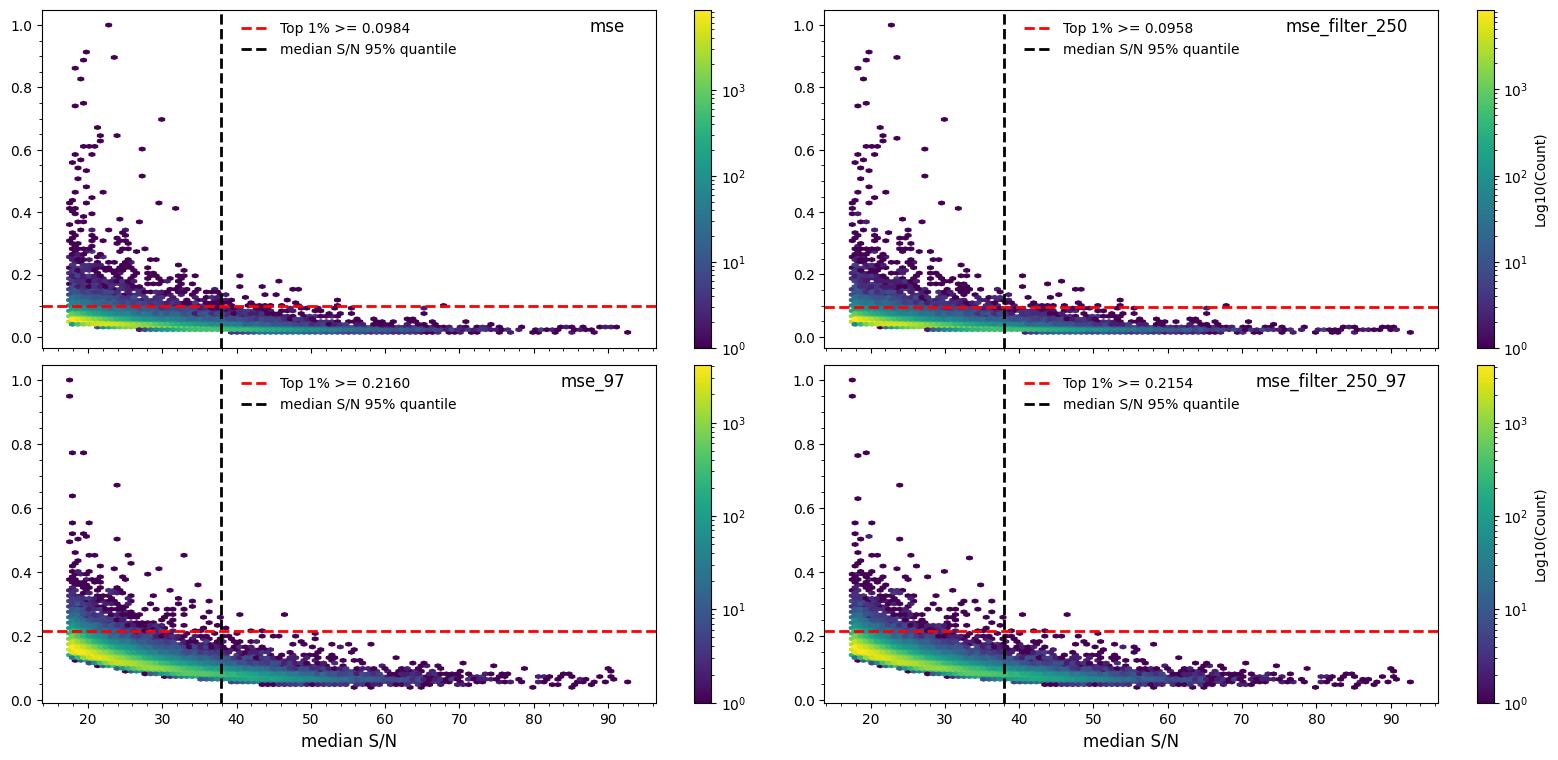

In [41]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_cols, 'snMedian', 'median S/N')

for i, score in enumerate(mse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    axs[i].axvline(
        x=top_snr_threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'median S/N {snr_quantile}% quantile'
    )

    axs[i].legend(frameon=False, loc='upper center')

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

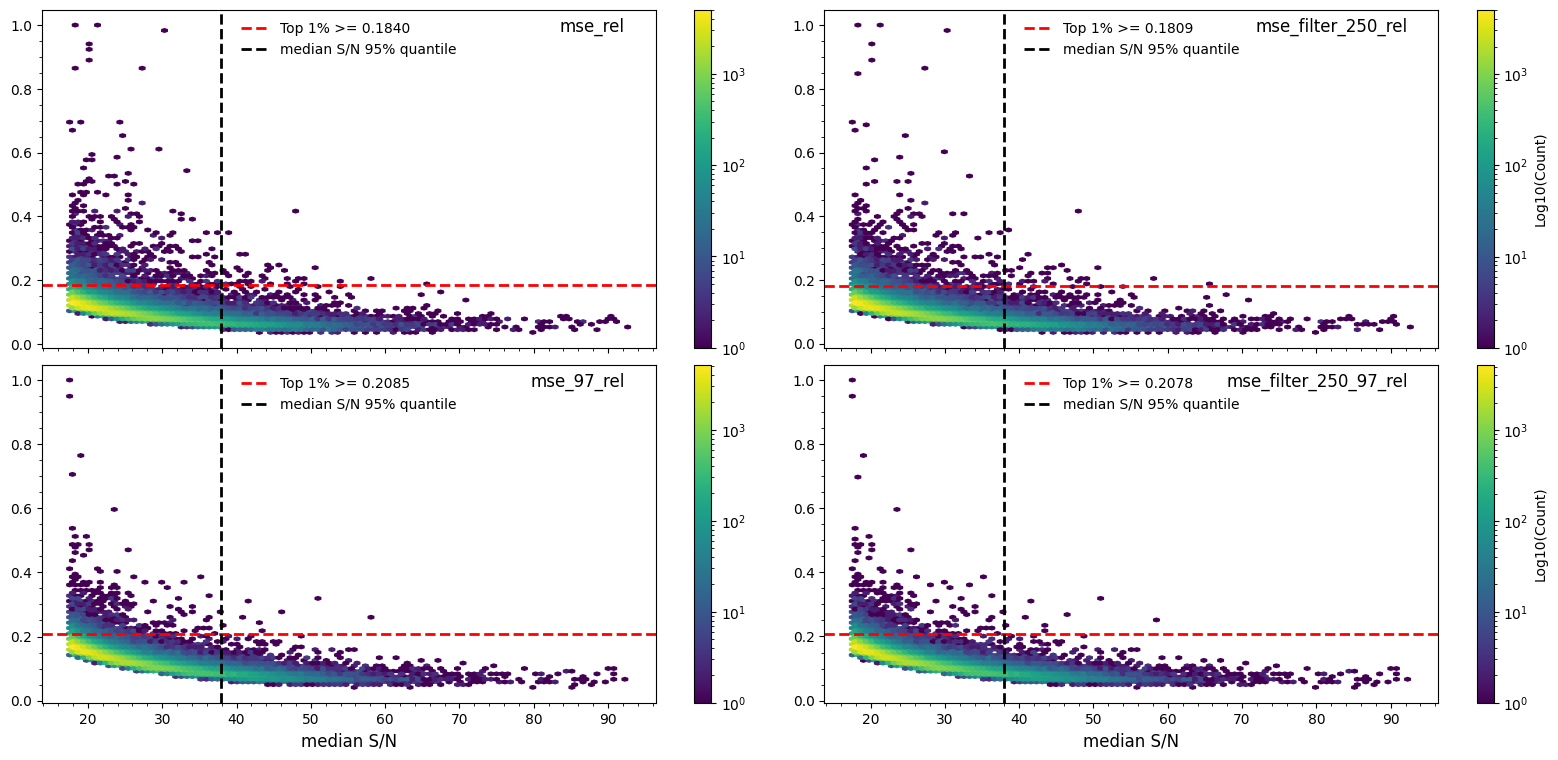

In [42]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_rel_cols, 'snMedian', 'median S/N')

for i, score in enumerate(mse_rel_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    
    axs[i].axvline(
        x=top_snr_threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'median S/N {snr_quantile}% quantile'
    )

    axs[i].legend(frameon=False, loc='upper center')

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)